# EDA

## Daten laden
europe-electricity-load-hourly-20192025 aus Kaggle manuell herunterladen und als csv einlesen

In [ ]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement core.data (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for core.data


In [ ]:
import kagglehub
import shutil
import os

dataset_link = "dsersun/europe-electricity-load-hourly-20192025"  # just the owner/dataset part
destination = "../data/raw"

cache_path = kagglehub.dataset_download(dataset_link)
#print(f"Downloaded to cache: {cache_path}")

os.makedirs(destination, exist_ok=True)

# Copy all files from cache to destination
for file in os.listdir(cache_path):
    shutil.copy(os.path.join(cache_path, file), destination)
    print(f"Copied: {file} → {destination}")

C:\Users\seewi\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to cache: C:\Users\seewi\.cache\kagglehub\datasets\dsersun\europe-electricity-load-hourly-20192025\versions\1
Copied: MHLV_2019_2025_combined.csv → ../data/raw


In [ ]:
import pandas as pd

# Load the dataset
file_path = "../data/raw/MHLV_2019_2025_combined.csv"
df_energy = pd.read_csv(file_path, parse_dates=['DateUTC', 'DateShort'])

display(df_energy.head())

print(df_energy.info())

print(df_energy.describe())

,MeasureItem,DateUTC,DateShort,TimeFrom,TimeTo,CountryCode,Cov_ratio,Value,Value_ScaleTo100,year
0,Monthly Hourly Load Values,2019-01-01 00:00:00,2019-01-01,1970-01-01 00:00:00,1970-01-01 01:00:00,AT,100,5852.5,5852.5,2019
1,Monthly Hourly Load Values,2019-01-01 01:00:00,2019-01-01,1970-01-01 01:00:00,1970-01-01 02:00:00,AT,100,5619.2,5619.2,2019
2,Monthly Hourly Load Values,2019-01-01 02:00:00,2019-01-01,1970-01-01 02:00:00,1970-01-01 03:00:00,AT,100,5323.9,5323.9,2019
3,Monthly Hourly Load Values,2019-01-01 03:00:00,2019-01-01,1970-01-01 03:00:00,1970-01-01 04:00:00,AT,100,5273.3,5273.3,2019
4,Monthly Hourly Load Values,2019-01-01 04:00:00,2019-01-01,1970-01-01 04:00:00,1970-01-01 05:00:00,AT,100,5439.0,5439.0,2019


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071728 entries, 0 to 2071727
Data columns (total 10 columns):
 #   Column            Dtype         
---  ------            -----         
 0   MeasureItem       object        
 1   DateUTC           datetime64[ns]
 2   DateShort         datetime64[ns]
 3   TimeFrom          object        
 4   TimeTo            object        
 5   CountryCode       object        
 6   Cov_ratio         int64         
 7   Value             float64       
 8   Value_ScaleTo100  float64       
 9   year              int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(4)
memory usage: 158.1+ MB
None
                             DateUTC                      DateShort  \
count                        2071728                        2071728   
mean   2022-05-31 21:57:29.807117824  2022-05-31 10:27:35.369430784   
min              2019-01-01 00:00:00            2019-01-01 00:00:00   
25%              2020-09-23 12:00:00            2020-09-23 

In [18]:
print('MeasureItem unique values:')
print(df_energy['MeasureItem'].unique())

print('Cov_ratio unique values:')
print(df_energy['Cov_ratio'].unique())

print('CountryCode value counts:')
print(df_energy['CountryCode'].value_counts())

print('Compare Value and Value_ScaleTo100 columns:')
print(df_energy[df_energy['Value']!=df_energy[ 'Value_ScaleTo100']].head())

MeasureItem unique values:
['Monthly Hourly Load Values']
Cov_ratio unique values:
[100]
CountryCode value counts:
CountryCode
AT    59160
BE    59160
BG    59160
IT    59160
FI    59160
DE    59160
PL    59160
SE    59160
NL    59160
HR    59160
LU    59160
PT    59160
ME    59160
CH    59159
ES    59159
LV    59159
NO    59159
HU    59158
LT    59158
CZ    59154
EE    59153
DK    59152
RS    59152
GR    59152
SK    59137
FR    59094
SI    59078
RO    59077
MK    56184
BA    54532
IE    52989
MD    49417
GB    42011
XK    36038
CY    33513
GE    32220
AL    31440
UA    27203
Name: count, dtype: int64
Compare Value and Value_ScaleTo100 columns:
Empty DataFrame
Columns: [MeasureItem, DateUTC, DateShort, TimeFrom, TimeTo, CountryCode, Cov_ratio, Value, Value_ScaleTo100, year]
Index: []


In [25]:
df_energy = df_energy.drop(columns=['DateShort', 'MeasureItem', 'TimeFrom', 'TimeTo', 'Cov_ratio', 'Value_ScaleTo100'], axis=1)
df_energy = df_energy.rename(columns={'Value': 'EnergyDemand'})
df_energy.head()


,DateUTC,CountryCode,EnergyDemand,year
0,2019-01-01 00:00:00,AT,5852.5,2019
1,2019-01-01 01:00:00,AT,5619.2,2019
2,2019-01-01 02:00:00,AT,5323.9,2019
3,2019-01-01 03:00:00,AT,5273.3,2019
4,2019-01-01 04:00:00,AT,5439.0,2019


In [20]:
df_energy.isna().sum()

DateUTC         0
DateShort       0
CountryCode     0
EnergyDemand    0
year            0
dtype: int64

In [26]:
df_energy['hour'] = df_energy['DateUTC'].dt.hour
df_energy['weekday'] = df_energy['DateUTC'].dt.dayofweek
df_energy['month'] = df_energy['DateUTC'].dt.month
df_energy['is_weekend'] = (df_energy['DateUTC'].dt.weekday >= 5).astype(int)
df_energy.head()

,DateUTC,CountryCode,EnergyDemand,year,hour,weekday,month,is_weekend
0,2019-01-01 00:00:00,AT,5852.5,2019,0,1,1,0
1,2019-01-01 01:00:00,AT,5619.2,2019,1,1,1,0
2,2019-01-01 02:00:00,AT,5323.9,2019,2,1,1,0
3,2019-01-01 03:00:00,AT,5273.3,2019,3,1,1,0
4,2019-01-01 04:00:00,AT,5439.0,2019,4,1,1,0


In [27]:
df_energy_de = df_energy[df_energy['CountryCode'] == 'DE']
df_energy_de = df_energy_de.drop(columns=['CountryCode'], axis=1)

df_energy_de.to_csv("../data/energy_demand_de_2019_2025.csv", index=False)

In [2]:
%pip install holidays

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# add public holidays for Germany
import pandas as pd
import holidays 

df_energy_de = pd.read_csv("../data/energy_demand_de_2019_2025.csv", parse_dates=['DateUTC'])
de_holidays = holidays.Germany(years=range(2019, 2026))
df_energy_de['is_holiday'] = df_energy_de['DateUTC'].dt.date.apply(lambda x: 1 if x in de_holidays else 0)

# add holiday ratio depending the number of states in Germany with a holiday on that day
def holiday_ratio(date):
    count = sum([1 for state in holidays.Germany(years=[date.year]).items() if state[0] == date])
    return count / 16   
df_energy_de['holiday_ratio'] = df_energy_de['DateUTC'].dt.date.apply(holiday_ratio)

In [8]:
df_energy_de.to_csv("../data/energy_demand_de_2019_2025.csv", index=False)

In [6]:
df_energy_de.head()

,DateUTC,EnergyDemand,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio
0,2019-01-01 00:00:00,41653.9575,2019,0,1,1,0,1,0.0625
1,2019-01-01 01:00:00,40113.5800,2019,1,1,1,0,1,0.0625
2,2019-01-01 02:00:00,39312.9375,2019,2,1,1,0,1,0.0625
3,2019-01-01 03:00:00,39097.1625,2019,3,1,1,0,1,0.0625
4,2019-01-01 04:00:00,38634.3500,2019,4,1,1,0,1,0.0625


In [7]:
df_energy_de.describe()

,DateUTC,EnergyDemand,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio
count,59160,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000
mean,2022-05-17 11:30:00.365111808,54663.227387,2021.888032,11.500101,2.999189,6.355375,0.285598,0.024341,0.001521
min,2019-01-01 00:00:00,30908.880000,2019.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2020-09-08 05:45:00,46803.277500,2020.000000,5.750000,1.000000,3.000000,0.000000,0.000000,0.000000
50%,2022-05-17 11:30:00,54517.358750,2022.000000,11.500000,3.000000,6.000000,0.000000,0.000000,0.000000
75%,2024-01-23 17:15:00,62177.330000,2024.000000,17.250000,5.000000,9.000000,1.000000,0.000000,0.000000
max,2025-09-30 23:00:00,81077.455000,2025.000000,23.000000,6.000000,12.000000,1.000000,1.000000,0.062500
std,NaN,9666.896304,1.949594,6.922113,2.000017,3.396644,0.451703,0.154106,0.009632


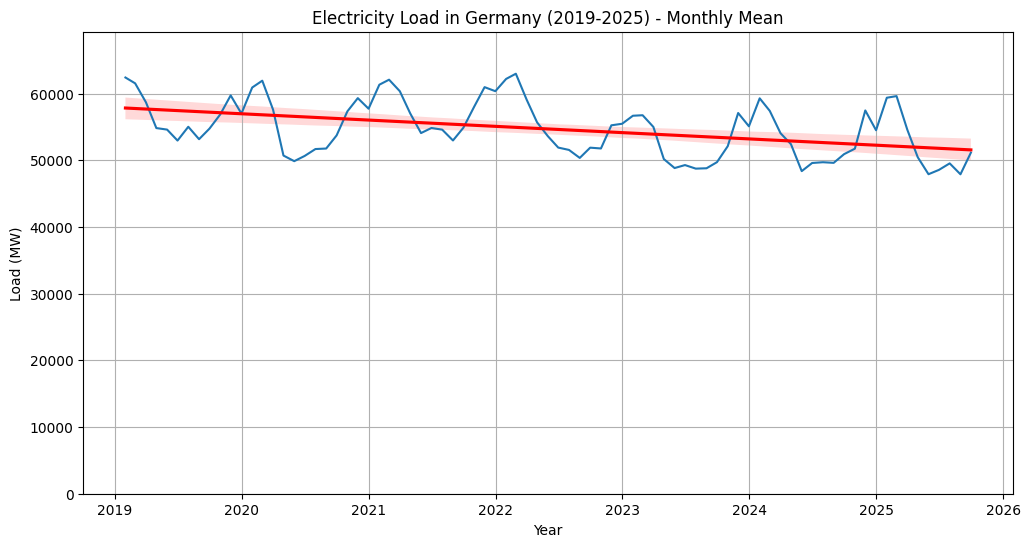

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd   

df_energy_de = pd.read_csv("../data/energy_demand_de_2019_2025.csv", parse_dates=['DateUTC'])

df_monthly = df_energy_de.set_index('DateUTC')['EnergyDemand'].resample('ME').mean().reset_index()

# Convert dates to float for regression
df_monthly['DateNum'] = mdates.date2num(df_monthly['DateUTC'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df_monthly, x='DateUTC', y='EnergyDemand', ax=ax)
plt.title('Electricity Load in Germany (2019-2025) - Monthly Mean')

# add trend line
sns.regplot(data=df_monthly, x='DateNum', y='EnergyDemand',
            scatter=False, color='red', label='Trend Line', ax=ax)

plt.ylim(0, df_monthly['EnergyDemand'].max() * 1.1)
plt.grid()
plt.xlabel('Year')
plt.ylabel('Load (MW)')
plt.show()

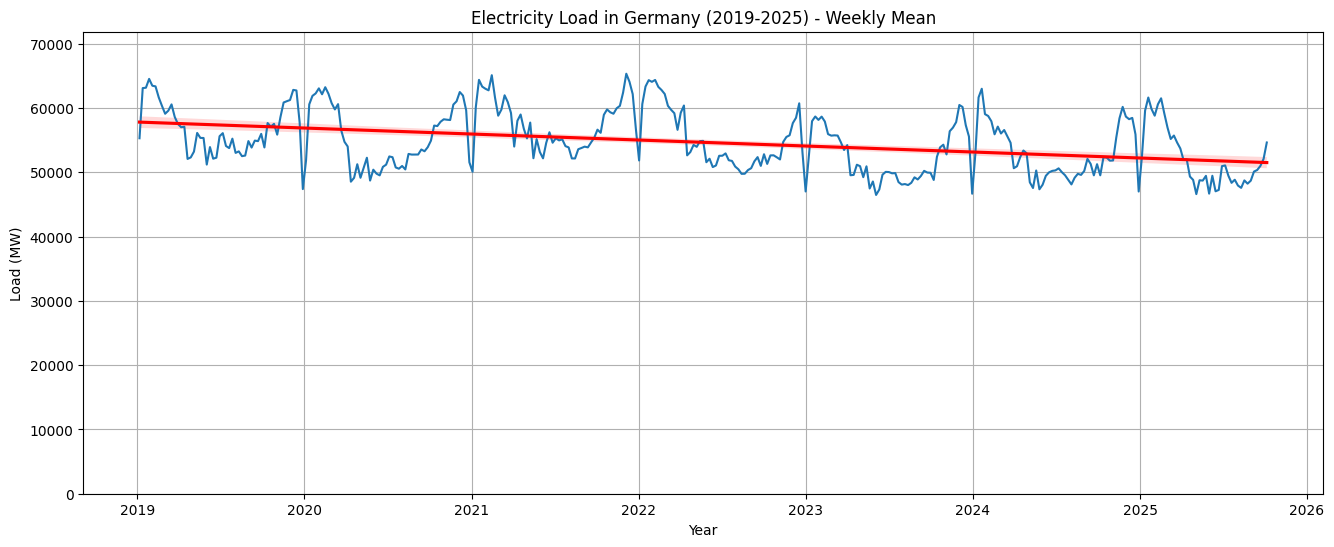

In [6]:
df_weekly = df_energy_de.set_index('DateUTC')['EnergyDemand'].resample('W').mean().reset_index()
# Convert dates to float for regression
df_weekly['DateNum'] = mdates.date2num(df_weekly['DateUTC'])

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(data=df_weekly, x='DateUTC', y='EnergyDemand', ax=ax)
plt.title('Electricity Load in Germany (2019-2025) - Weekly Mean')

# add trend line
sns.regplot(data=df_weekly, x='DateNum', y='EnergyDemand',
            scatter=False, color='red', label='Trend Line', ax=ax)

plt.ylim(0, df_weekly['EnergyDemand'].max() * 1.1)
plt.grid()
plt.xlabel('Year')
plt.ylabel('Load (MW)')
plt.show()

* additive model - seasonal values and redisual independent on trend

### time series decomposition

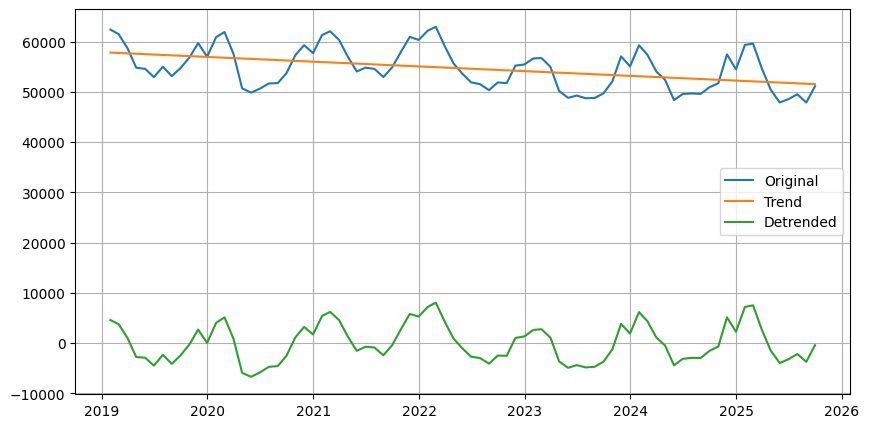

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_energy_de = pd.read_csv("../data/energy_demand_de_2019_2025.csv", parse_dates=['DateUTC'])
df_monthly = df_energy_de.set_index('DateUTC')['EnergyDemand'].resample('ME').mean().reset_index()
df_monthly.set_index('DateUTC', inplace=True)
# Convert dates to float for regression
df_monthly['DateNum'] = mdates.date2num(df_monthly.index)

slope, intercept = np.polyfit(df_monthly['DateNum'], df_monthly['EnergyDemand'], 1) # estimate line coefficient
trend = df_monthly['DateNum'] * slope + intercept # linear trend
detrended = df_monthly['EnergyDemand'] - trend # remove the trend

plt.figure(figsize=(10, 5))
plt.plot(df_monthly['EnergyDemand'], label='Original')
plt.plot(trend, label='Trend')
plt.plot(detrended, label='Detrended')

plt.grid()
plt.legend()
plt.show()

In [5]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 4.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.6 MB 4.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.6 MB 4.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 4.6 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 4.6 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.6 MB 4.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 4.6 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.6 MB 4.6 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 4.5 MB/s  0:00:02

   ----------------


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


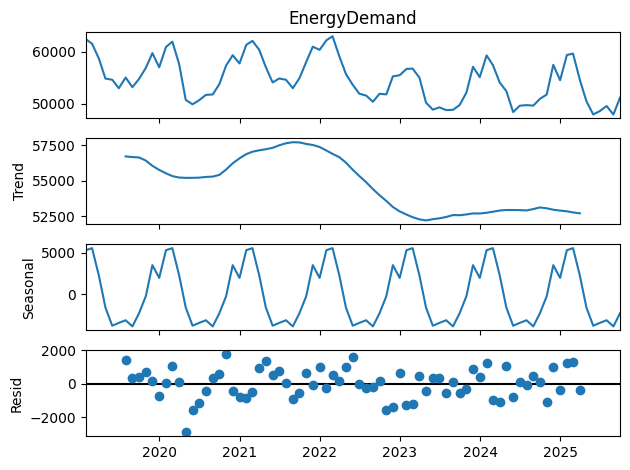

In [ ]:
# decompose seasonality using seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose     
#df_monthly.set_index('DateUTC', inplace=True)
decomposition = seasonal_decompose(df_monthly['EnergyDemand'], model='additive', period=12) # monthly data, so period is 12 months
decomposition.plot();  # use ; to avoid doubled plot. the returned figure is already plotted by the function, so we just suppress the output to avoid a second empty plot.

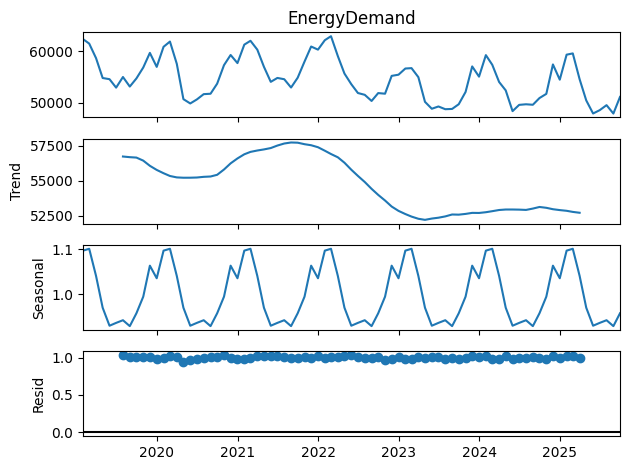

In [ ]:
# decompose seasonality using seasonal_decompose with multiplicative model
from statsmodels.tsa.seasonal import seasonal_decompose     
#df_monthly.set_index('DateUTC', inplace=True)
decomposition = seasonal_decompose(df_monthly['EnergyDemand'], model='multiplicative', period=12) # monthly data, so period is 12 months
decomposition.plot();  # use ; to avoid doubled plot. the returned figure is already plotted by the function, so we just suppress the output to avoid a second empty plot.
decomposition

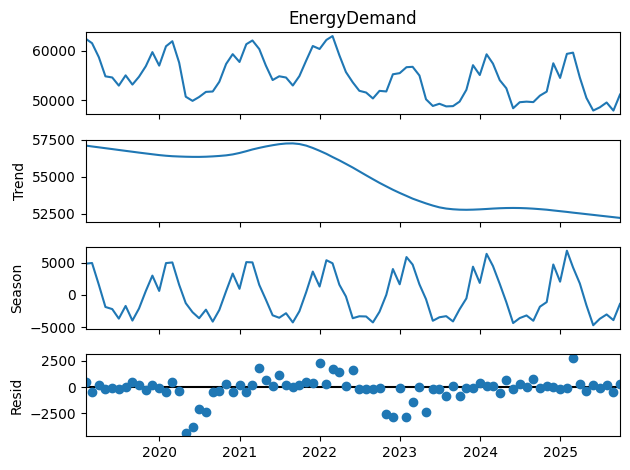

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from scipy.fft import fft
np.random.seed(0)  # for reproducibility

stl_decomposition = STL(endog=df_monthly['EnergyDemand'], period=12, robust=True).fit()
stl_decomposition.plot();  # use ; to avoid doubled plot. the returned figure is already plotted by the function, so we just suppress the output to avoid a second empty plot.